# Practical Workshop 1 — Autograd from Scratch

Last session you learned about tensors. Today we'll use them, and one extra PyTorch tool called autograd, to build and train a neural network.

Understanding how this is done at the fundamental level helps in understanding what PyTorch abstractions are doing.

## Part 0 — The main new concept: `requires_grad`

When you create a tensor with `requires_grad=True`, PyTorch will track each operation done with this tensor. The reason is that, when you call `.backward()` on a scalar that depends on it, PyTorch will walk through the chain of operations backwards, computing successive gradients, and filling in the final gradient in `.grad` via autograd.

Let's see it on an easy function which we can quickly validate.

Consider the function $y(x) = 3x^2 + 2x + 1$. It can easily shown that $\frac{dy}{dx} = 6x + 2$.

As an example, evaluating the derivative at $x=4$ yields, $\frac{dy}{dx}\Bigr|_{x=4} = 26$. Let's see how to compute this using PyTorch.

In [1]:
import torch

x = torch.tensor(4.0, requires_grad=True)
y = 3 * x**2 + 2 * x + 1
y.backward()

print("dy/dx at x=4 =", x.grad.item())
print("Expected: 26.0")

dy/dx at x=4 = 26.0
Expected: 26.0


**What just happened?**

1. We defined `x` as a _leaf_ tensor, set with `requires_grad=True`. PyTorch then kept track of all the operations made using `x` as we computed `y`. This tracking of operations is done using a computational graph.
2. `y.backward()` ran the chain rule backwards through that computational graph to compute the accumulative derivative.
3. The final gradient was then stored in `x.grad`.

That's the entire mechanism. Everything we do from here just stacks more operations between `x` and `y`.

### Very Important Consideration: gradients accumulate

If you call `.backward()` again, the new gradient gets added to whatever is already in `.grad`. PyTorch does this so you can sum gradients across batches of data if you want. To deal with this, in your training loop **you must remember to zero the gradients** at every step.

Let's see this.

In [2]:
x = torch.tensor(4.0, requires_grad=True)

for step in range(3):
    y = 3 * x**2 + 2 * x + 1
    y.backward()
    print(f"step {step}: x.grad = {x.grad.item()}")


step 0: x.grad = 26.0
step 1: x.grad = 52.0
step 2: x.grad = 78.0


As you can see, the gradient is accumulated each time we call `.backward()`. To fix this, we simply use `.grad.zero_()` to zero the gradient before the next iteration.

In [3]:
x = torch.tensor(4.0, requires_grad=True)

for step in range(3):
    if x.grad is not None:
        x.grad.zero_()
    y = 3 * x**2 + 2 * x + 1
    y.backward()
    print(f"step {step}: x.grad = {x.grad.item()}")


step 0: x.grad = 26.0
step 1: x.grad = 26.0
step 2: x.grad = 26.0


## Part 1 — Linear regression from scratch

Let's fit a linear regression line to the model: $y_i = \beta_0 + \beta_1 x_i + \epsilon_i$, where $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$. 

### 1.1 Make some fake data

We'll generate data from a known true line $y = 10x - 5$, corrupted by Gaussian noise with standard deviation = 4. Then, we'll see if our model can recover the true parameters.

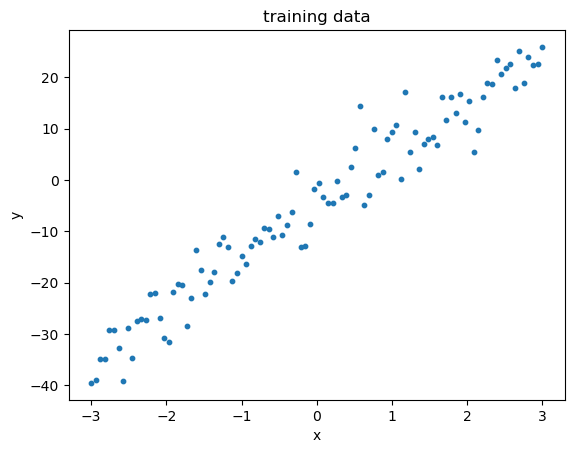

In [4]:
import matplotlib.pyplot as plt
torch.manual_seed(0)

# Define the true parameters that our model should try and learn
true_beta0, true_beta1 = -5.0, 10.0

num_samples = 100
x = torch.linspace(-3, 3, num_samples)
y = true_beta0 + true_beta1 * x + 4 * torch.randn(num_samples)

plt.scatter(x, y, s=10)
plt.xlabel("x"); plt.ylabel("y")
plt.title("training data")
plt.show()


### 1.2 The Training Loop

The following defines a standard training loop which lies at the heart of nearly all training pipelines:

1. **Forward** — predict $\hat{y}$ from $x$ using the current parameters model parameters $(\hat{\beta_0}, \hat{\beta_1})$.
2. **Loss** — measure how wrong the prediction is.
3. **Backward** — call `.backward()` on the loss to get gradients.
4. **Step** — update the parameters in the direction that reduces the loss.
5. **Zero** — clear the gradients before the next iteration.

In [5]:
# Parameters with requires_grad=True so autograd tracks them
beta0 = torch.zeros(1, requires_grad=True)
beta1 = torch.zeros(1, requires_grad=True)

beta0_hist, beta1_hist = [], []

lr = 0.05
n_epochs = 100
losses = []

for epoch in range(n_epochs):
    # 1) FORWARD
    y_hat = beta0 + beta1 * x

    # 2) LOSS — mean squared error
    loss = ((y_hat - y) ** 2).mean()

    # 3) BACKWARD
    loss.backward()

    # 4) STEP — update under no_grad so the update itself isn't tracked
    with torch.no_grad():
        beta0 -= lr * beta0.grad
        beta1 -= lr * beta1.grad

    # 5) ZERO the gradients for the next epoch.
    beta0.grad.zero_()
    beta1.grad.zero_()

    losses.append(loss.item())

    # Just for fun, let's track the parameter values. Not done in practice.
    beta0_hist.append(beta0.item())
    beta1_hist.append(beta1.item())

print(f"Learned beta0 = {beta0.item():.3f}  (true = {true_beta0})")
print(f"Learned beta1 = {beta1.item():.3f}  (true = {true_beta1})")


Learned beta0 = -4.851  (true = -5.0)
Learned beta1 = 9.998  (true = 10.0)


### 1.3 Visualize the training results

Plot the loss curve and the learned line. Since we tracked the history of the parameters, we can also plot how the model parameters evolved in parameter space over the training phase.

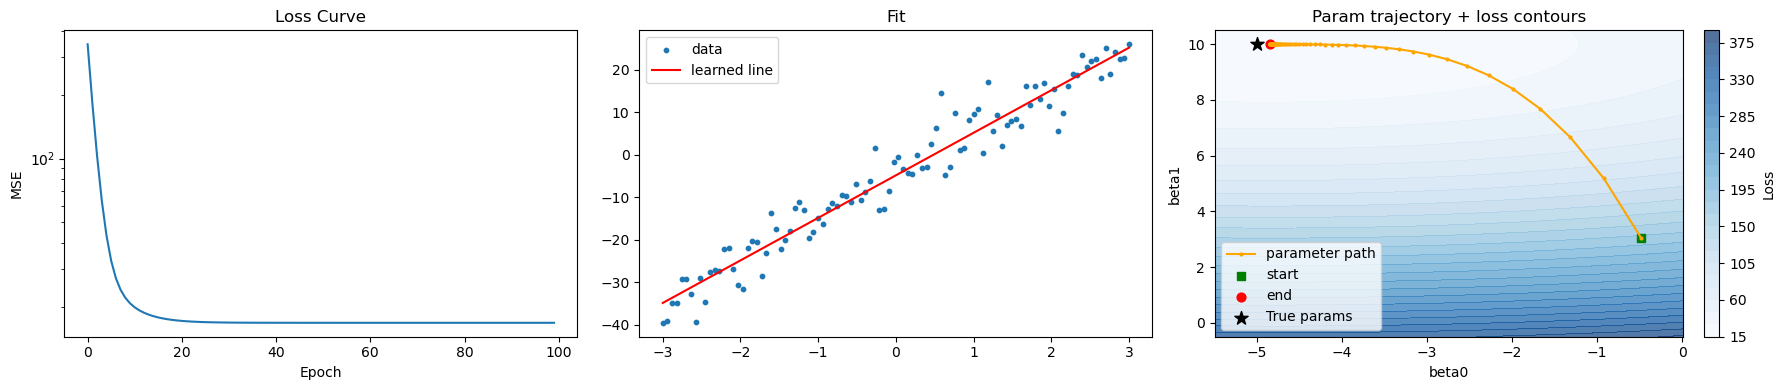

In [6]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

## Plot loss curve
axes[0].plot(losses)
axes[0].set_yscale("log")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")

## Plot our model's fit
axes[1].scatter(x, y, s=10, label="data")
with torch.no_grad():
    axes[1].plot(x, beta0 + beta1 * x, color="red", label="learned line")
axes[1].legend();
axes[1].set_title("Fit")

## Plot trajectory with loss contours in (beta0, beta1) space
ax = axes[2]

beta0_min = min([0.0, true_beta0, min(beta0_hist)]) - 0.5
beta0_max = max([true_beta0, max(beta0_hist)]) + 0.5
beta1_min = min([0.0, true_beta1, min(beta1_hist)]) - 0.5
beta1_max = max([true_beta1, max(beta1_hist)]) + 0.5

# Compute mesh of beta parameters to compute loss at each point
beta0_vals = np.linspace(beta0_min, beta0_max, 100)
beta1_vals = np.linspace(beta1_min, beta1_max, 100)
beta0_grid, beta1_grid = np.meshgrid(beta0_vals, beta1_vals)
loss_grid = np.zeros_like(beta0_grid)

x_np = x.numpy()
y_np = y.numpy()
for i in range(beta0_grid.shape[0]):
    for j in range(beta0_grid.shape[1]):
        y_hat_grid = beta0_grid[i, j] + beta1_grid[i, j] * x_np
        loss_grid[i, j] = np.mean((y_hat_grid - y_np) ** 2)

# Plot contour
contour = ax.contourf(beta0_vals, beta1_vals, loss_grid, levels=30, cmap="Blues", alpha=0.7)
cbar = plt.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Loss")

# Plot parameter path
ax.plot(beta0_hist, beta1_hist, marker='o', markersize=2, linewidth=1.5, color='orange', label="parameter path")
ax.scatter([beta0_hist[0]], [beta1_hist[0]], color='green', marker='s', s=40, label='start')
ax.scatter([beta0_hist[-1]], [beta1_hist[-1]], color='red', marker='o', s=40, label='end')
ax.scatter([true_beta0], [true_beta1], c="black", marker="*", s=100, label="True params")

ax.set_xlabel("beta0")
ax.set_ylabel("beta1")
ax.set_xlim(beta0_min, beta0_max)
ax.set_ylim(beta1_min, beta1_max)
ax.set_title("Param trajectory + loss contours")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


## Part 2 — A 2-layer neural network from scratch

Linear regression is a one-layer affine model. A neural network is just more of these stacked together with a non-linearity between them.

Specifically, a 2-layer network with a `ReLU` non-linearity looks like:

$$h = \text{ReLU}(x W_1 + b_1)$$
$$\hat{y} = h W_2 + b_2$$

Where:
- $W_1$ is shape `(input_dim, hidden_dim)`
- $W_2$ is shape `(hidden_dim, output_dim)`
- ReLU is just `max(0, ·)` applied element-wise

Let's fit a sine wave.

### 2.1 Make a non-linear dataset

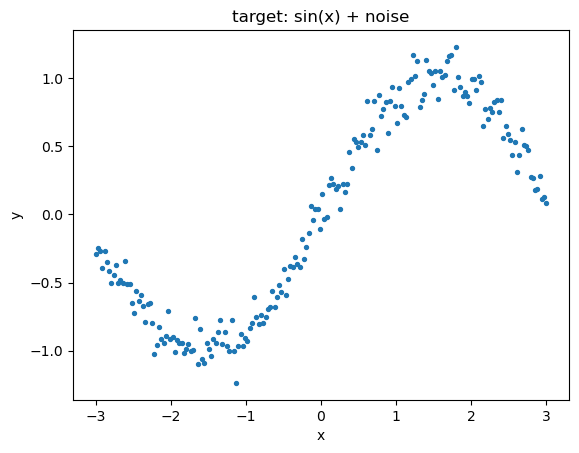

In [7]:
torch.manual_seed(1)

num_samples = 200
x = torch.linspace(-3, 3, num_samples).unsqueeze(1)        # shape (N, 1)
y = torch.sin(x) + 0.1 * torch.randn(num_samples, 1)       # shape (N, 1)

plt.scatter(x, y, s=8)
plt.title("target: sin(x) + noise"); plt.xlabel("x"); plt.ylabel("y")
plt.show()


### 2.2 Initialise the parameters

A 2-layer network has four parameter tensors: $W_1, b_1, W_2, b_2$. These are initialized to some base values before training begins.

**Tip on parameter initialization:** If we start with all zeros, `ReLU` will set everything to 0 and learn nothing. Instead, we initialize them to small random numbers. (We'll cover proper initialization later on.)

In [8]:
input_dim, hidden_dim, output_dim = 1, 32, 1

w1 = (torch.randn(input_dim, hidden_dim) * 0.5).requires_grad_(True)
b1 = torch.zeros(hidden_dim, requires_grad=True)
w2 = (torch.randn(hidden_dim, output_dim) * 0.5).requires_grad_(True)
b2 = torch.zeros(output_dim, requires_grad=True)

print("W1 shape:", w1.shape)
print("W2 shape:", w2.shape)


W1 shape: torch.Size([1, 32])
W2 shape: torch.Size([32, 1])


### 2.3 The forward pass as a function

To improve readibility of the code, it's typical to wrap the forward pass in a function. Use `torch.relu` for the activation.

In [9]:
def forward(x):
    pre_activation  = x @ w1 + b1
    post_activation = torch.relu(pre_activation)
    
    y_hat = post_activation @ w2 + b2

    return y_hat

### 2.4 The same five-step loop

Notice this loop is *identical in structure* to the linear regression one — just with more parameters to update.

In [10]:
params = [w1, b1, w2, b2]
lr = 0.01
num_epochs = 2000
losses = []

for epoch in range(num_epochs):
    # 1) FORWARD
    y_hat = forward(x)

    # 2) LOSS
    loss = ((y_hat - y) ** 2).mean()

    # 3) BACKWARD
    loss.backward()

    # 4) STEP
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad

    # 5) ZERO
    for p in params:
        p.grad.zero_()

    losses.append(loss.item())
    if epoch % 200 == 0:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")


epoch    0  loss 0.6512
epoch  200  loss 0.0685
epoch  400  loss 0.0447
epoch  600  loss 0.0344
epoch  800  loss 0.0287
epoch 1000  loss 0.0251
epoch 1200  loss 0.0225
epoch 1400  loss 0.0204
epoch 1600  loss 0.0187
epoch 1800  loss 0.0173


### 2.5 Visualize the training results

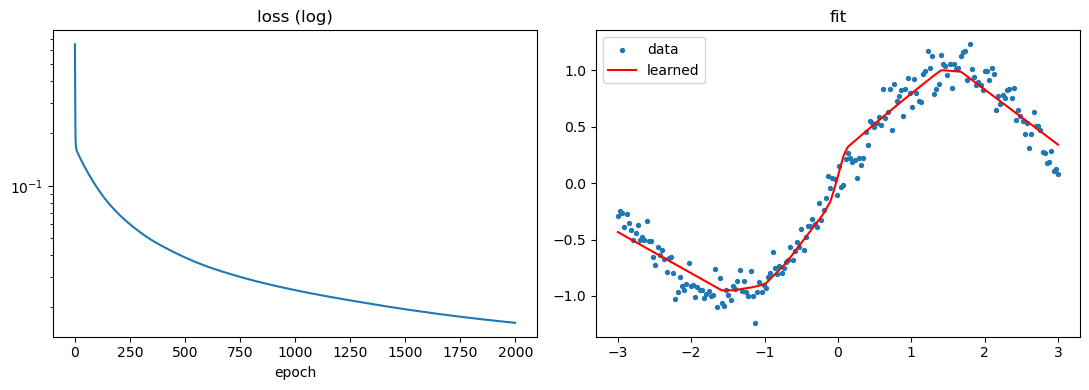

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(losses)
axes[0].set_yscale("log")
axes[0].set_title("loss (log)")
axes[0].set_xlabel("epoch")

axes[1].scatter(x, y, s=8, label="data")
with torch.no_grad():
    Xs = torch.linspace(-3, 3, 200).unsqueeze(1)
    axes[1].plot(Xs, forward(Xs), color="red", label="learned")
axes[1].legend(); 
axes[1].set_title("fit")
plt.tight_layout(); plt.show()


And, that's it! You've now coded up a neural network and gradient descent training algorithm from scratch. The model has 65 parameters (`1*32 + 32 + 32*1 + 1`), all learned from data.

## Part 3 — A general network builder

So far we've hand-written `W1, b1, W2, b2`. Let's write a single function that builds a network of any shape from a list of layer sizes. This will make it easier to try and get a smoother fit.


We'll use the following notation `[1, 64, 64, 1]`. This means, input dim 1 → hidden layer 1 dim 64 → hidden layer 2 dim 64 → output 1.

### 3.1 The builder

We will use the **Kaiming/He** (`std = sqrt(2 / n_in)`) initialization, which keeps signal well-scaled through many layers. (More on this in later sessions.)

In [12]:
import math

def build_mlp(layer_sizes, seed=0):
    """
    Builds a multi-layer perceptron with the given layer sizes.

    Args:
        layer_sizes (list): A list of integers representing the number of neurons in each layer.
        seed (int): The seed for the random number generator.

    Returns:
        params (list): A list of tuples, where each tuple contains a weight matrix and a bias vector.
    """
    torch.manual_seed(seed)

    params = []

    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = (torch.randn(n_in, n_out) * math.sqrt(2.0 / n_in)).requires_grad_(True)
        b = torch.zeros(n_out, requires_grad=True)
        params.append((W, b))

    return params

### 3.2 A general forward pass that works for any depth

Apply each layer in turn, with an activation on every layer **except the last**. 

In [13]:
def forward(x, params, activation=torch.relu):
    h = x
    for i, (W, b) in enumerate(params):
        h = h @ W + b
        if i < len(params) - 1:      # no activation on the output layer
            h = activation(h)
    return h

def all_tensors(params):
    flat = []
    for W, b in params:
        flat.extend([W, b])
    return flat

### 3.3 A reusable general training function

We can now construct the same five-step training loop as before, just looping over a parameter list of any length.

In [14]:
def train(layer_sizes, X, y, activation=torch.relu, lr=0.01, num_epochs=4000, seed=0):
    params = build_mlp(layer_sizes, seed=seed)
    flat   = all_tensors(params)

    losses = []

    for epoch in range(num_epochs):
        y_hat = forward(X, params, activation)
        loss  = ((y_hat - y) ** 2).mean()
        loss.backward()

        with torch.no_grad():
            for p in flat:
                p -= lr * p.grad

        for p in flat:
            p.grad.zero_()

        losses.append(loss.item())

    return params, losses

### 3.4 Making the fit less "liney"

Our earlier fit looked like connected straight-line segments. **ReLU is piecewise-linear.** Each unit is one hinge, so a `ReLU` network's output is always made of straight segments. Adding more hidden layers will result in shorter segmenets, and a somewhat smoother looking fit. However, it will not be completely smooth.


Using a smooth activation function, like`tanh`, which is differentiable everywhere, will result in neural network fits that look smoother. We'll touch upon different activation functions in a later session.

### 3.5 Understanding the role of width, depth, and learning rate

In [15]:
import matplotlib.pyplot as plt

torch.manual_seed(1)
num_samples = 200
x = torch.linspace(-3, 3, num_samples).unsqueeze(1)
y = torch.sin(x) + 0.1 * torch.randn(num_samples, 1)
x_test = torch.linspace(-3, 3, 400).unsqueeze(1)

First, let's observe the effect of increasing the number of hidden layers, but keeping the width fixed.

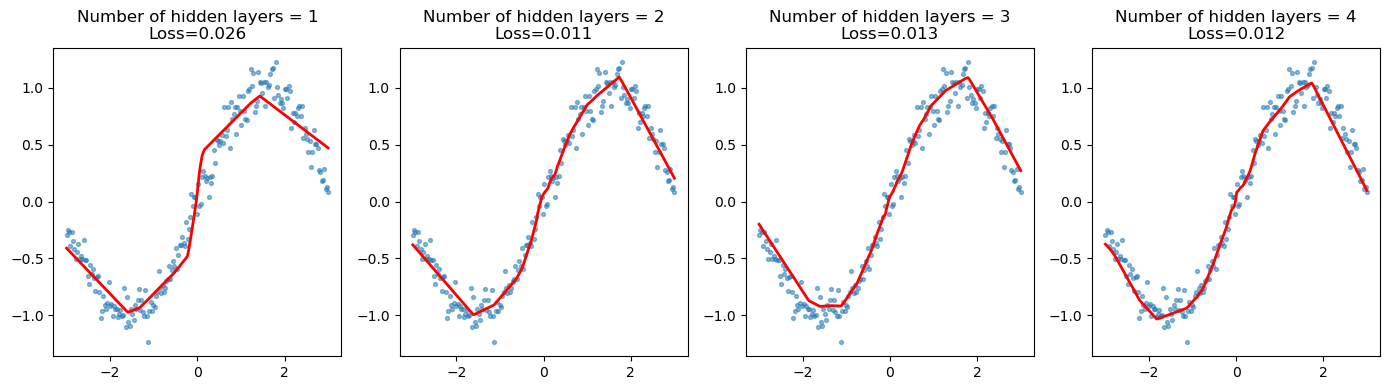

In [20]:
runs_layers = [
    ("1 hidden",      [1, 32, 1]),
    ("2 hidden",      [1, 32, 32, 1]),
    ("3 hidden",      [1, 32, 32, 32, 1]),
    ("4 hidden",      [1, 32, 32, 32, 32, 1])
]

fig, axes = plt.subplots(1, len(runs_layers), figsize=(14, 4))
for ax, (lbl, sizes) in zip(axes, runs_layers):
    params, losses = train(sizes, x, y, activation=torch.relu, lr=0.01, num_epochs=4000)
    ax.scatter(x, y, s=8, alpha=0.5)
    with torch.no_grad():
        ax.plot(Xs, forward(Xs, params, torch.relu), color="red", linewidth=2.0)
    ax.set_title(f"Number of hidden layers = {len(sizes)-2}\nLoss={losses[-1]:.3f}")
plt.tight_layout()
plt.show()

Next, let's observe the effect of increasing both depth and width

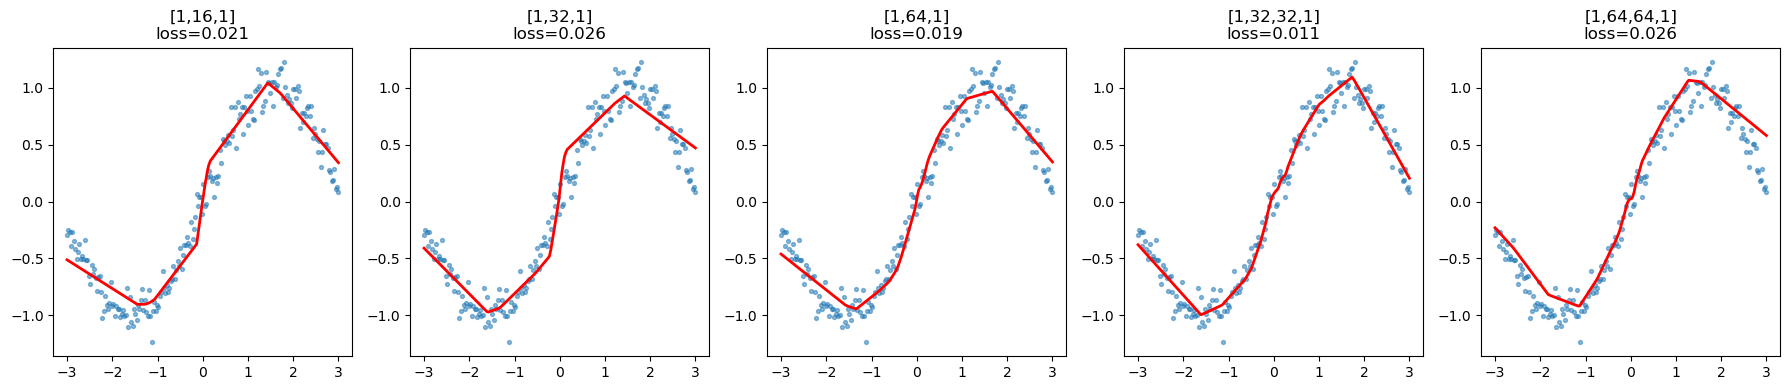

In [23]:
runs_wide = [
    ("[1,16,1]",    [1, 16, 1]),
    ("[1,32,1]",    [1, 32, 1]),
    ("[1,64,1]",    [1, 64, 1]),
    ("[1,32,32,1]", [1, 32, 32, 1]),
    ("[1,64,64,1]", [1, 64, 64, 1]),
]

fig, axes = plt.subplots(1, len(runs_wide), figsize=(18, 4))
for ax, (lbl, sizes) in zip(axes, runs_wide):
    params, losses = train(sizes, x, y, activation=torch.relu, lr=0.01, num_epochs=4000)
    ax.scatter(x, y, s=8, alpha=0.5)
    with torch.no_grad():
        ax.plot(Xs, forward(Xs, params, torch.relu), color="red", linewidth=2.0)
    ax.set_title(f"{lbl}\nloss={losses[-1]:.3f}")
plt.tight_layout()
plt.show()

Finally, let's oberve the effect of learning rate on training performance

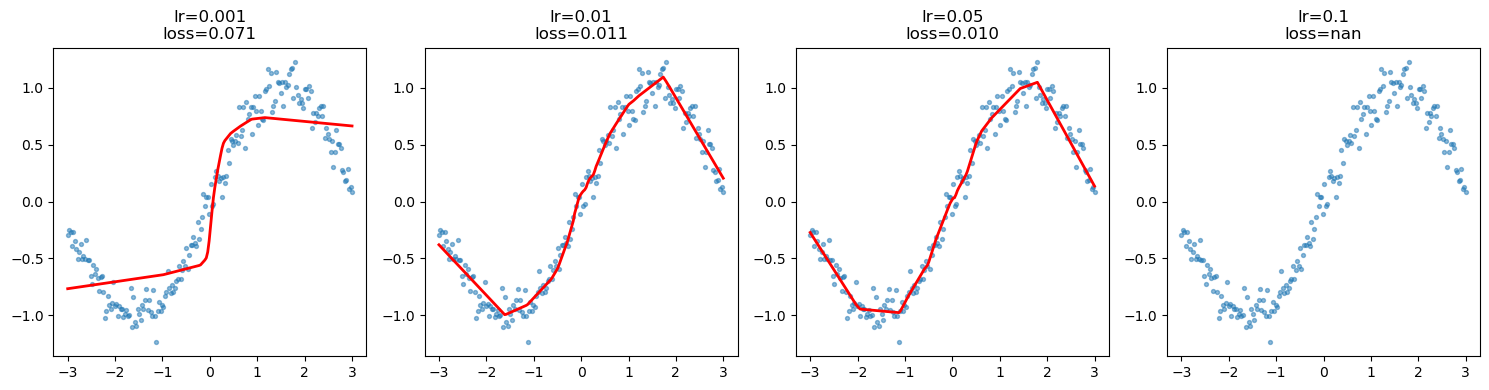

In [26]:
runs_lr = [
    ("lr=0.001", [1, 32, 32, 1], 0.001),
    ("lr=0.01",  [1, 32, 32, 1], 0.01),
    ("lr=0.05",  [1, 32, 32, 1], 0.05),
    ("lr=0.1",   [1, 32, 32, 1], 0.1),
]

fig, axes = plt.subplots(1, len(runs_lr), figsize=(15, 4))
for ax, (lbl, sizes, lr) in zip(axes, runs_lr):
    params, losses = train(sizes, x, y, activation=torch.relu, lr=lr, num_epochs=4000)
    ax.scatter(x, y, s=8, alpha=0.5)
    with torch.no_grad():
        ax.plot(Xs, forward(Xs, params, torch.relu), color="red", linewidth=2.0)
    ax.set_title(f"{lbl}\nloss={losses[-1]:.3f}")
plt.tight_layout()
plt.show()


## Recap

Today, you've built a neural network from tensors and the chain rule. Specifically:

1. **`requires_grad=True`** turns on autograd (gradient tracking) for a PyTorch tensor.
2. **`.backward()`** computes gradients via the chain rule.
3. **Gradients accumulate** — remember to zero them at every step.
4. **The five-step training loop**: forward → loss → backward → step → zero.
5. **A 2-layer network** is just two linear layers with a non-linearity in between.

### Next: Workshop 2 — *nn.Module, activations, and optim*
PyTorch offers a wide variety of pre-built tools for building and training neural networks. You'll learn how to write your own `nn.Module` and become more aware of common activation functions and optimizers.